In [15]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [16]:
df = df[df['job_title_short']== 'Data Analyst']
df_exploded = df.explode('job_skills')

In [ ]:
df_exploded[['job_title_short', 'job_skills', 'salary_year_avg']].dropna()

,job_title_short,job_skills,salary_year_avg
109,Data Analyst,python,89000.0
109,Data Analyst,r,89000.0
109,Data Analyst,alteryx,89000.0
109,Data Analyst,tableau,89000.0
180,Data Analyst,excel,90250.0
...,...,...,...
784882,Data Analyst,alteryx,87500.0
785187,Data Analyst,sql,111175.0
785187,Data Analyst,python,111175.0
785187,Data Analyst,r,111175.0


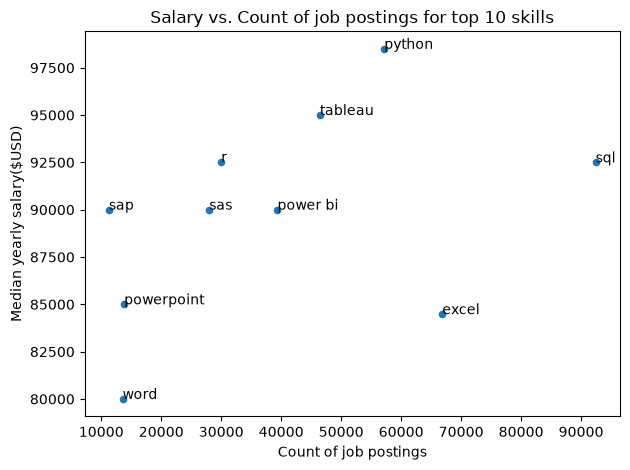

In [46]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'),
    median_salary = ('salary_year_avg', 'median')
)
skill_stats = skill_stats.sort_values(by = 'skill_count', ascending = False).head(10)
lists= skill_stats.index
skill_stats.plot(kind = 'scatter', x = 'skill_count', y ='median_salary')
plt.xlabel('Count of job postings')
plt.ylabel('Median yearly salary($USD)')
plt.title('Salary vs. Count of job postings for top 10 skills')

for txt in skill_stats.index:
    plt.text(skill_stats.loc[txt,'skill_count'], skill_stats.loc[txt,'median_salary'], txt)
plt.tight_layout()
